# **MLProcess - Air Quality**
---
**Data Understanding (EDA)**

In [1]:
# Import the required libraries
import yaml
import joblib
import numpy as np
import pandas as pd

# Need to be installed
import seaborn as sns
import scipy.stats as scs
import matplotlib.pyplot as plt

## **1 - Configuration File**
---

In [2]:
# Function to load configuration parameter.
def load_config(path_config):
    """
    Load the configuration file.

    Parameters:
    ------
    path_config : str
        Configuration file location.

    Returns:
    ------
    params : dict
        Loaded configuration file.
    """
    
    # Try to Load config.yaml file.
    try:
        with open(path_config, 'r') as file:
            params = yaml.safe_load(file)
    except FileNotFoundError as err:
        raise RuntimeError(f'Configuration file not found in {path_config}')

    return params

In [3]:
# Load the configuration file
PATH_CONFIG = '../config/config.yaml'
config = load_config(PATH_CONFIG)

In [4]:
# Check the configuration parameters
config

{'columns_datetime': ['tanggal'],
 'columns_int': ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max'],
 'columns_object': ['stasiun', 'critical', 'category'],
 'features': ['stasiun', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2'],
 'impute_co': 11.63883089770355,
 'impute_no2': 19.330076762037685,
 'impute_o3': 32.06298655343242,
 'impute_pm10': {'BAIK': 28.426573426573427, 'TIDAK BAIK': 55.32202052091555},
 'impute_pm25': {'BAIK': 39.35454545454545, 'TIDAK BAIK': 82.33438237608182},
 'impute_so2': 35.15479651162791,
 'label': 'category',
 'label_categories': ['BAIK', 'SEDANG', 'TIDAK SEHAT'],
 'label_categories_new': ['BAIK', 'TIDAK BAIK'],
 'path_clean_test': ['../data/processed/X_test_clean.pkl',
  '../data/processed/y_test_clean.pkl'],
 'path_clean_train': ['../data/processed/X_train_clean.pkl',
  '../data/processed/y_train_clean.pkl'],
 'path_clean_valid': ['../data/processed/X_valid_clean.pkl',
  '../data/processed/y_valid_clean.pkl'],
 'path_data_joined': '../data/interim/joined_datas

## **2 - Load Data**
---
**Note**: Do EDA only on the train set.

In [5]:
# Load the train set
X_train = joblib.load(config['path_data_train'][0])
y_train = joblib.load(config['path_data_train'][1])

In [6]:
# Join X_train and y_train
dataset = pd.concat(
    [X_train, y_train],
    axis = 1
)

In [7]:
# Check the joined train set
dataset

,stasiun,pm10,pm25,so2,co,o3,no2,category
233,DKI3 (Jagakarsa),62,93,26,15,36,10,SEDANG
1699,DKI1 (Bunderan HI),62,89,26,12,34,34,SEDANG
967,DKI2 (Kelapa Gading),31,34,38,8,53,9,SEDANG
435,DKI5 (Kebon Jeruk) Jakarta Barat,25,44,22,5,15,21,BAIK
1199,DKI5 (Kebon Jeruk) Jakarta Barat,70,114,33,11,30,22,TIDAK SEHAT
...,...,...,...,...,...,...,...,...
141,DKI5 (Kebon Jeruk) Jakarta Barat,53,78,-1,7,25,16,SEDANG
1333,DKI4 (Lubang Buaya),51,78,37,12,23,19,SEDANG
1483,DKI4 (Lubang Buaya),57,-1,26,34,39,7,SEDANG
201,DKI2 (Kelapa Gading),47,58,29,11,51,14,SEDANG


## **3 - Explanatory Data Analysis**
---
1. Missing Value Check
2. Skewness Check
3. Data Split
4. Visualization
5. Hypothesis Test
6. Imbalanced Label Check
7. Outliers Check

### **3.1. Missing Value Check**

In [8]:
# Replace the -1 values with NaN
dataset = dataset.replace(-1, np.nan)

In [9]:
# Check the number of missing values
dataset.isnull().sum()

stasiun      0
pm10        40
pm25        69
so2         74
co          13
o3          37
no2         17
category     0
dtype: int64

### **3.2. Skewness Check**

In [10]:
# Fisher-Pearson Skew values
dataset.skew(numeric_only=True)

pm10   -0.216203
pm25    0.256014
so2     0.090188
co      1.844090
o3      1.556290
no2     0.855157
dtype: float64

**Insights:**
- `pm10` is left skewed, but not significant. The rest are right skewed.
- `co`, `o3`, and `no2` have skew values > 0.5, indicating a lot of outliers. We will impute using its median.
- The rest will be imputed using its mean.

### **3.3. Data Split**
Split the data by its class.

In [11]:
dataset_baik = dataset[dataset['category'] == 'BAIK'].copy()
dataset_tidak_baik = dataset[dataset['category'] != 'BAIK'].copy()

In [12]:
# Kelas 1 => BAIK
dataset_baik.describe()

,pm10,pm25,so2,co,o3,no2
count,143.000000,110.000000,147.000000,151.000000,148.000000,142.000000
mean,28.426573,39.354545,24.312925,8.867550,26.290541,11.056338
std,7.517575,8.748878,10.377665,4.474633,11.478020,6.765342
min,14.000000,13.000000,3.000000,2.000000,7.000000,3.000000
25%,23.000000,34.250000,17.000000,6.000000,16.000000,6.000000
50%,28.000000,41.000000,22.000000,8.000000,24.000000,9.000000
75%,32.000000,47.000000,31.500000,11.000000,36.250000,15.000000
max,50.000000,50.000000,50.000000,28.000000,49.000000,49.000000


In [13]:
# Kelas 0 => SEDANG & TIDAK SEHAT
dataset_tidak_baik.describe()

,pm10,pm25,so2,co,o3,no2
count,1267.000000,1271.000000,1229.000000,1286.000000,1265.000000,1291.000000
mean,55.322021,82.334382,36.451587,11.964230,32.738340,20.240124
std,12.718753,21.940092,12.139404,4.885805,14.718573,8.715110
min,19.000000,19.000000,2.000000,3.000000,9.000000,1.000000
25%,49.000000,67.500000,27.000000,9.000000,23.000000,14.000000
50%,55.000000,80.000000,37.000000,11.000000,29.000000,19.000000
75%,63.000000,95.000000,46.000000,14.000000,39.000000,25.000000
max,95.000000,174.000000,82.000000,47.000000,151.000000,65.000000


**Insights:**
- `pm10` and `pm25` mean between class 0 and 1 have a significant difference. We will impute using class mean.
- `so2` mean between class 0 dan 1 have a slight difference. We will impute using the mean.
- `co`, `o3`, and `no2` median between calss 0 and 1 have a slight difference. We will impute using the median.

### **3.4. Visualization**

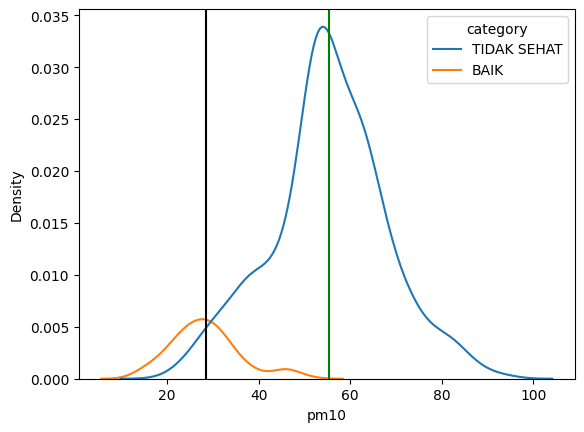

In [14]:
# pm10 column distribution
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = 'pm10',
    hue = 'category'
)
plt.axvline(dataset_tidak_baik['pm10'].mean(), 0, 1, color='g')
plt.axvline(dataset_baik['pm10'].mean(), 0, 1, color='k')
plt.show()

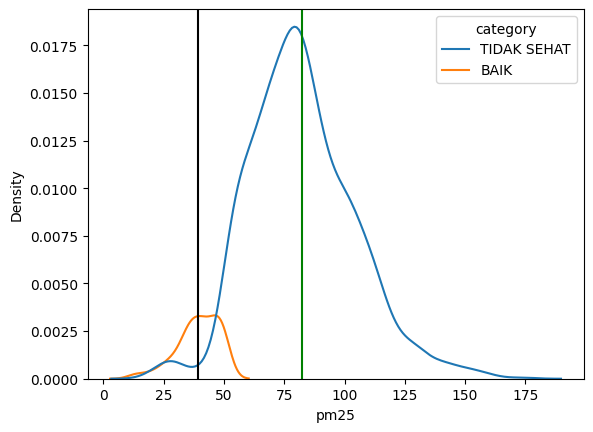

In [15]:
# pm25 column distribution
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = 'pm25',
    hue = 'category'
)
plt.axvline(dataset_tidak_baik['pm25'].mean(), 0, 1, color='g')
plt.axvline(dataset_baik['pm25'].mean(), 0, 1, color='k')
plt.show()

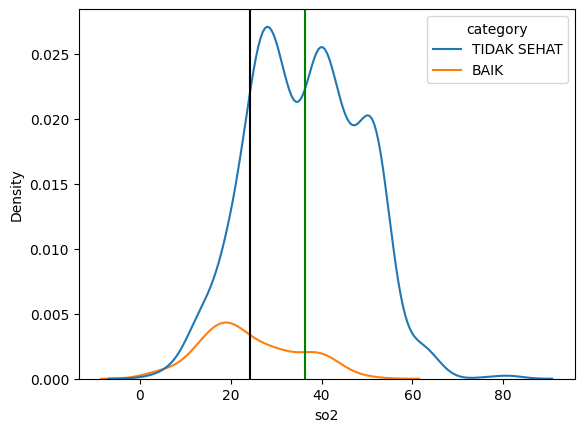

In [16]:
# so2 column distribution
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = 'so2',
    hue = 'category'
)
plt.axvline(dataset_tidak_baik['so2'].mean(), 0, 1, color='g')
plt.axvline(dataset_baik['so2'].mean(), 0, 1, color='k')
plt.show()

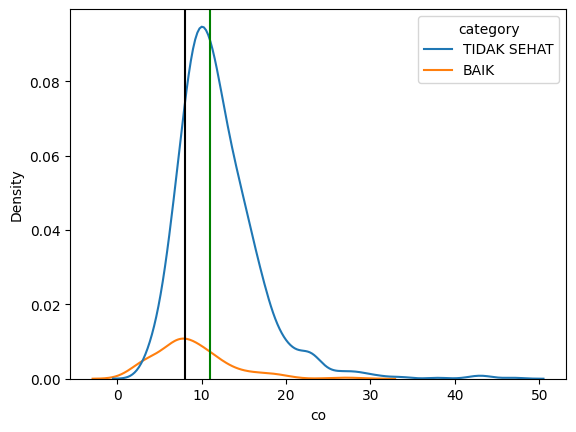

In [17]:
# co column distribution
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = 'co',
    hue = 'category'
)
plt.axvline(dataset_tidak_baik['co'].median(), 0, 1, color='g')
plt.axvline(dataset_baik['co'].median(), 0, 1, color='k')
plt.show()

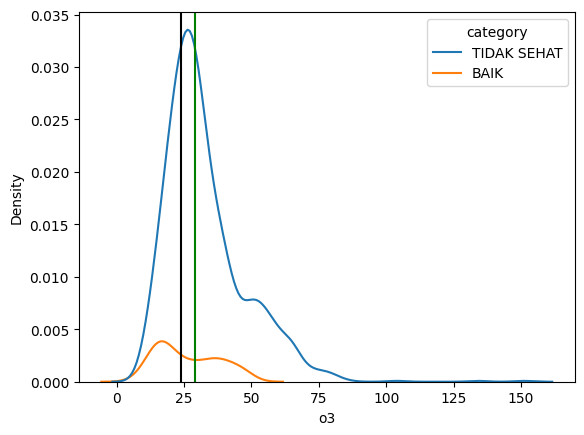

In [18]:
# o3 column distribution
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = 'o3',
    hue = 'category'
)
plt.axvline(dataset_tidak_baik['o3'].median(), 0, 1, color='g')
plt.axvline(dataset_baik['o3'].median(), 0, 1, color='k')
plt.show()

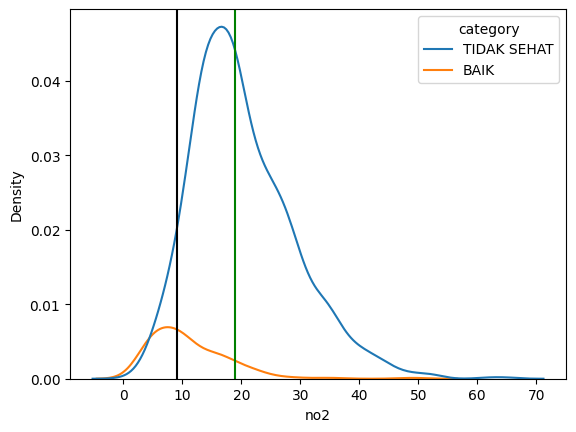

In [19]:
# no2 column distribution
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = 'no2',
    hue = 'category'
)
plt.axvline(dataset_tidak_baik['no2'].median(), 0, 1, color='g')
plt.axvline(dataset_baik['no2'].median(), 0, 1, color='k')
plt.show()

Let's check the correlation.

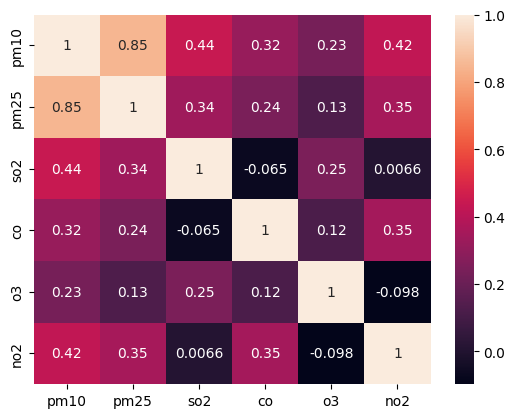

In [20]:
# Pearson Correlation
sns.heatmap(
    dataset.corr(numeric_only=True),
    annot=True
)
plt.show()

### **3.5. Hypothesis Test**
T-Test (to check mean between 2 variables)

**Note:**
- $h_0$ (null hypothesis): mean of class 0 == mean of class 1.
- $h_1$ (alternative hypothesis): mean of class 0 != mean of class 1.
- $h_0$ and $h_1$ is mutually exclusive (if $h_0$ is true, $h_1$ is false, and vice versa).
- The goal of the test is to determine whether to reject the $h_0$.

In [21]:
# pm10 t-value
scs.ttest_ind(
    dataset_baik[dataset_baik['pm10'].isnull() != True].pm10,
    dataset_tidak_baik[dataset_tidak_baik['pm10'].isnull() != True].pm10
)

TtestResult(statistic=np.float64(-24.798134939530886), pvalue=np.float64(6.145188073333482e-113), df=np.float64(1408.0))

In [22]:
# t-critical for alpha=0.05 and dof=n-2
scs.t.ppf(0.05, df=(len(dataset) - 2))

np.float64(-1.6459066313849768)

**Insights:**
- If $t_{value}$ $<$ $t_{critical}$ and $p_{value}$ $<$ $0.05$, then $h_0$ is rejected.
- Summary: `pm10` mean between class 0 and class 1 is statistically significant.

In [23]:
# pm25 t-value
scs.ttest_ind(
    dataset_baik[dataset_baik['pm25'].isnull() != True].pm25,
    dataset_tidak_baik[dataset_tidak_baik['pm25'].isnull() != True].pm25
)

TtestResult(statistic=np.float64(-20.40024644962354), pvalue=np.float64(4.701260236122959e-81), df=np.float64(1379.0))

In [24]:
# so2 t-value
scs.ttest_ind(
    dataset_baik[dataset_baik['so2'].isnull() != True].so2,
    dataset_tidak_baik[dataset_tidak_baik['so2'].isnull() != True].so2
)

TtestResult(statistic=np.float64(-11.625205913738137), pvalue=np.float64(7.282975026253746e-30), df=np.float64(1374.0))

In [25]:
# co t-value
scs.ttest_ind(
    dataset_baik[dataset_baik['co'].isnull() != True].co,
    dataset_tidak_baik[dataset_tidak_baik['co'].isnull() != True].co
)

TtestResult(statistic=np.float64(-7.430733333936815), pvalue=np.float64(1.847004333335102e-13), df=np.float64(1435.0))

In [26]:
# o3 t-value
scs.ttest_ind(
    dataset_baik[dataset_baik['o3'].isnull() != True].o3,
    dataset_tidak_baik[dataset_tidak_baik['o3'].isnull() != True].o3
)

TtestResult(statistic=np.float64(-5.148750637965434), pvalue=np.float64(2.9927389275816145e-07), df=np.float64(1411.0))

In [27]:
# no2 t-value
scs.ttest_ind(
    dataset_baik[dataset_baik['no2'].isnull() != True].no2,
    dataset_tidak_baik[dataset_tidak_baik['no2'].isnull() != True].no2
)

TtestResult(statistic=np.float64(-12.15924637383998), pvalue=np.float64(1.9196566876746638e-32), df=np.float64(1431.0))

### **3.6. Imbalanced Label Check**

In [28]:
# Check the proportion of the label
dataset['category'].value_counts(normalize=True)

category
SEDANG         0.720000
TIDAK SEHAT    0.175862
BAIK           0.104138
Name: proportion, dtype: float64

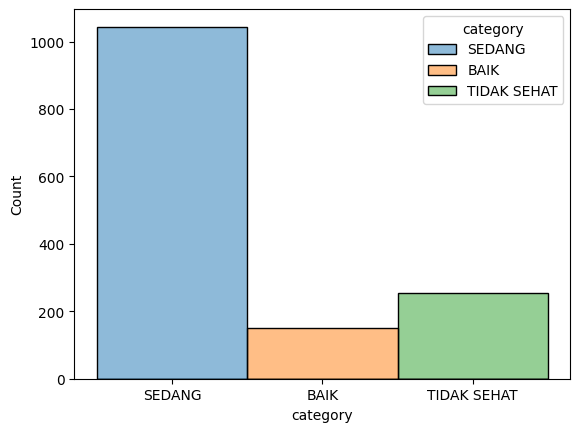

In [29]:
sns.histplot(
    data = dataset,
    x = 'category',
    hue = 'category'
)
plt.show()

### **3.7. Outliers Check**

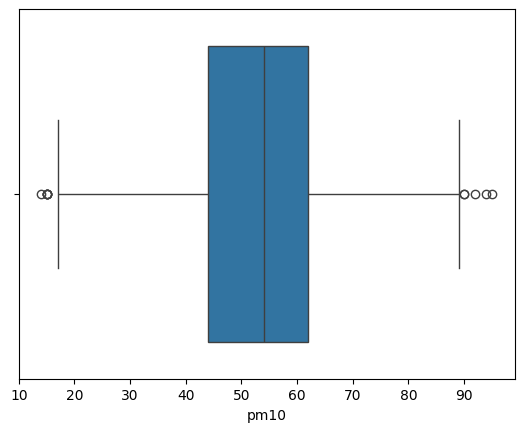

In [30]:
# pm10 boxplot
sns.boxplot(
    data = dataset,
    x = 'pm10'
)
plt.show()

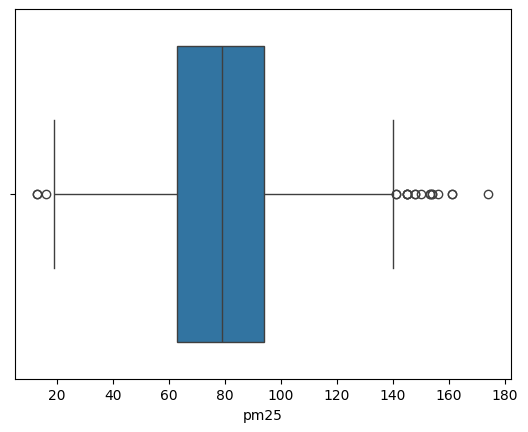

In [31]:
# pm25 boxplot
sns.boxplot(
    data = dataset,
    x = 'pm25'
)
plt.show()

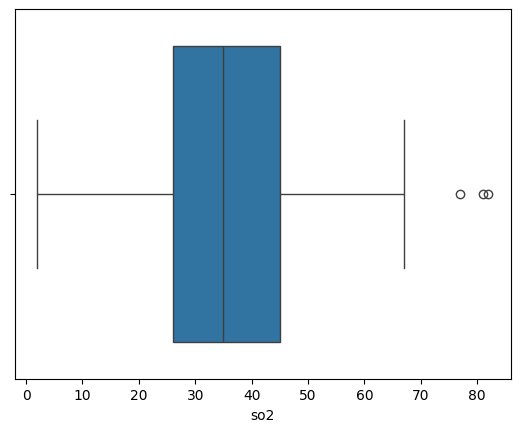

In [32]:
# so2 boxplot
sns.boxplot(
    data = dataset,
    x = 'so2'
)
plt.show()

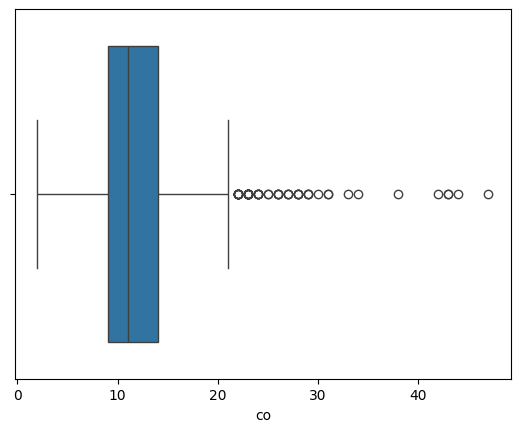

In [33]:
# co boxplot
sns.boxplot(
    data = dataset,
    x = 'co'
)
plt.show()

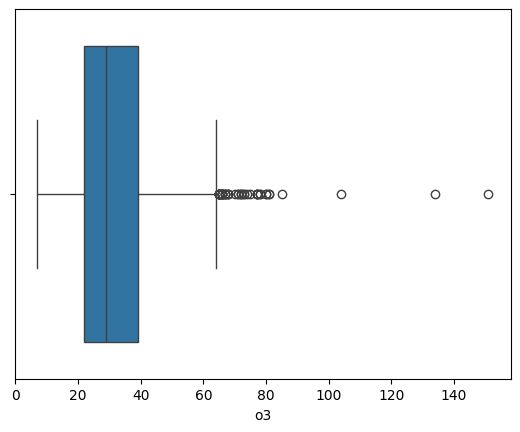

In [34]:
# o3 boxplot
sns.boxplot(
    data = dataset,
    x = 'o3'
)
plt.show()

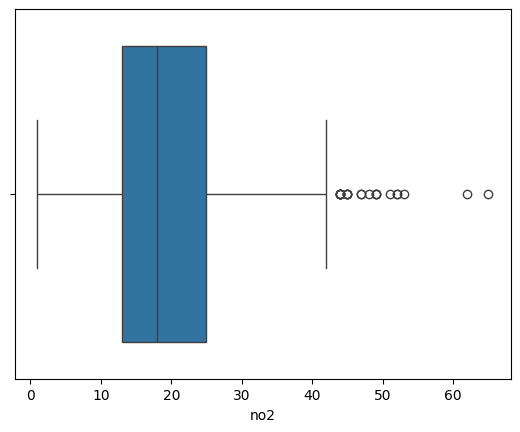

In [35]:
# no2 boxplot
sns.boxplot(
    data = dataset,
    x = 'no2'
)
plt.show()

**Summary:**
1. Missing Value Handling:
    - `pm10` and `pm25` : class mean
    - `so2` : mean
    - `co`, `o3`, and `no2` : median
2. Join label `SEDANG` and `TIDAK SEHAT` into `TIDAK BAIK`
3. Label balancing `BAIK` and `TIDAK BAIK`
4. Outliers removal